# Notebook 3: a frozen foundation model

M/EEG foundation models workshop · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/notebooks/03_fm_frozen.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Setup</div><div style="font-size:0.85em; color:#5B6472;">check · install · download</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Meet the data</div><div style="font-size:0.85em; color:#5B6472;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Classical baselines</div><div style="font-size:0.85em; color:#5B6472;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Frozen REVE</div><div style="font-size:0.85em; color:#C9D6E8;">embeddings · linear probe · few labels</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Fine-tuning</div><div style="font-size:0.85em; color:#5B6472;">demo · GPU optional</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Who won?</div><div style="font-size:0.85em; color:#5B6472;">one table · per person · statistics</div></td></tr></table>

Notebook 2 built two decoders that learn everything from one participant's day 1. This notebook uses **REVE**, a model that was trained beforehand on a very large amount of EEG from other people. We do not train REVE: we pass our trials through it, take the numbers it produces, and train a small classifier on them. The question is whether these numbers already contain what distinguishes the two hands. Same trials, same split and same scores as in notebook 2.

| Part | Content |
|---|---|
| 1 | What a foundation model is |
| 2 | How REVE reads a trial |
| 3 | The embeddings of our trials |
| 4 | A linear probe on one participant |
| 5 | Where is the information? |
| 6 | All participants, against the classical decoders |
| 7 | With fewer labels |
| 8 | Training on several participants |
| 9 | Go further (optional) |
| 10 | Summary |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Three kinds of blocks</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;the code is complete: run the cell and read the comments.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complete the one or two lines marked <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;optional: write the cell yourself, from hints and links to the documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Each exercise is followed by a folded solution. Run the solution before moving on: the next cells use its variables. Type 3 blocks can wait until after the session.</div></div>

In [1]:
# ---- Install (Colab only), imports and data folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"   # the tutorial repository
USE_DRIVE = True                                     # Colab: read the data that notebook 0 saved in your Google Drive

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import meeg_fm as mf                     # the tutorial package: data helpers, REVE, cached embeddings
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

mne.set_log_level("ERROR")                           # MNE only prints errors
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
                     "legend.frameon": False})
DATA_DIR = mf.use_data_dir()                         # the folder notebook 0 filled
RESULTS_DIR = (DATA_DIR if IN_COLAB else Path(".")) / "results"      # where the scores of every notebook are saved
RESULTS_DIR.mkdir(exist_ok=True)
print("Data folder:", DATA_DIR)

Data folder: ~/mne_data


In [2]:
# ---- Parameters
SUBJECT = 1                                  # the participant of parts 2 to 5
SUBJECTS = list(range(1, 10))                # parts 6 to 9 (slow computer or 3 participants downloaded: [1, 2, 3])
RUN_REVE = True                              # part 2 runs REVE on 8 trials (280 MB download the first time); False skips it
C = 0.01                                     # strength of the logistic regression's penalty (smaller = stronger)
HANDS = {"left_hand": "#1baf7a", "right_hand": "#4a3aa7"}                                   # colours of the two movements
COLORS = {"CSP + LDA": "#0B5CAD", "Tangent space + LR": "#E8710A", "REVE frozen + LR": "#7C3AED"}   # decoders

## 1. What a foundation model is

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A foundation model is trained once on a large amount of unlabelled EEG. We reuse it as a fixed machine that turns a trial into numbers.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: why it matters</b><br>Using a model frozen is the cheapest way to use it: no GPU, a classifier trained in a second. It also shows what pretraining alone has learned, before our labels change anything. If the frozen embeddings already separate the two hands, pretraining did the work.</div>

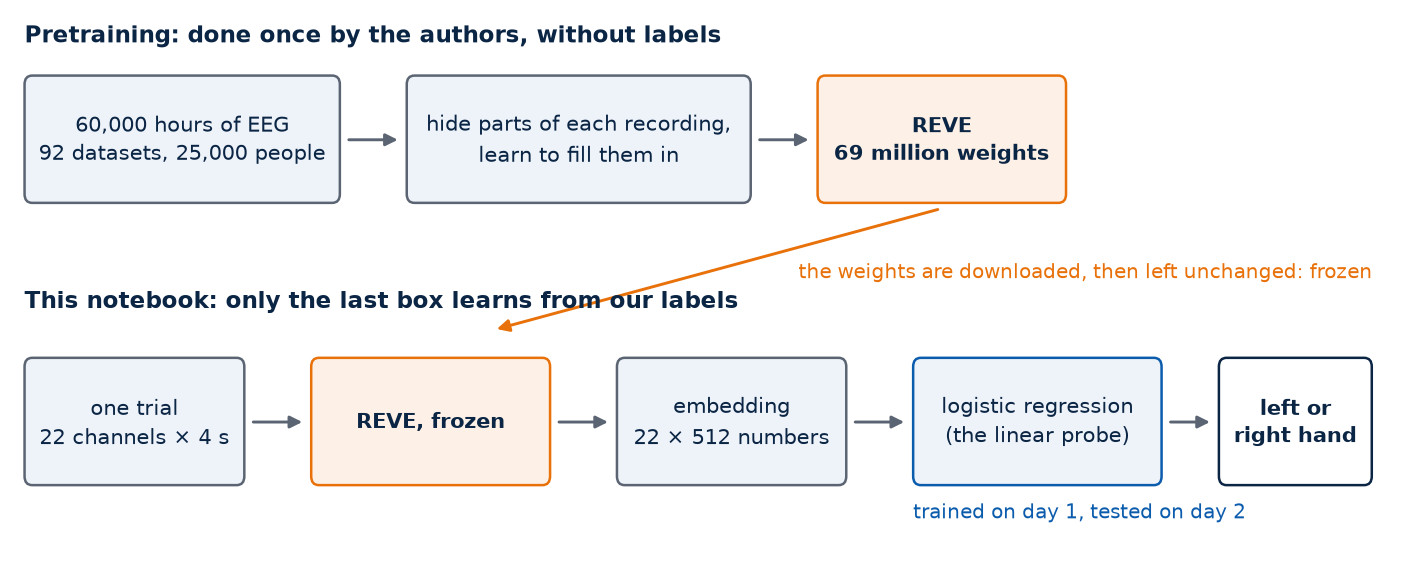

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: pretraining, self-supervised learning, frozen weights</b><br>A <b>foundation model</b> is a large neural network trained once on a very large and varied collection of data, then reused for many tasks. The first training is called <b>pretraining</b>. It needs no labels: the model is given recordings with pieces hidden and learns to fill them in. This is <b>self-supervised learning</b>, and to succeed the model has to pick up the regularities of EEG: rhythms, how neighbouring electrodes relate, what artefacts look like.<br>What the network has learned is stored in its <b>weights</b>, the millions of numbers that define its computations. We download them and choose how to use them. Here we keep them <b>frozen</b> (unchanged) and use the model as a fixed machine that turns a trial into numbers. Notebook 4 changes the weights instead, which is called <b>fine-tuning</b>.</div>

<div style="border-left:5px solid #5B6472; background:#F3F4F6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#5B6472;">The model</b><br><b>REVE</b> (El Ouahidi et al., 2025) was pretrained on about 60,000 hours of EEG from 92 datasets and 25,000 people. The version we use, <code>brain-bzh/reve-base</code>, has 69 million weights. According to the paper, BCI IV 2a was not part of the pretraining data: REVE has never seen our participants.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: embedding and linear probe</b><br>The numbers the model produces for a trial are its <b>embedding</b>, also called a <b>representation</b>. A <b>linear probe</b> is the simplest way to ask what an embedding contains: train a linear classifier on it, here a logistic regression, and look at its score. If a straight line is enough to separate left from right, the information was already laid out by the model. In the vocabulary of notebook 2, REVE replaces CSP and the tangent space: it is the step that makes the <b>features</b>.</div>

## 2. How REVE reads a trial

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>REVE reads a trial as 88 small pieces, each tagged with the position of its electrode and its time, and returns 512 numbers per piece.</div>

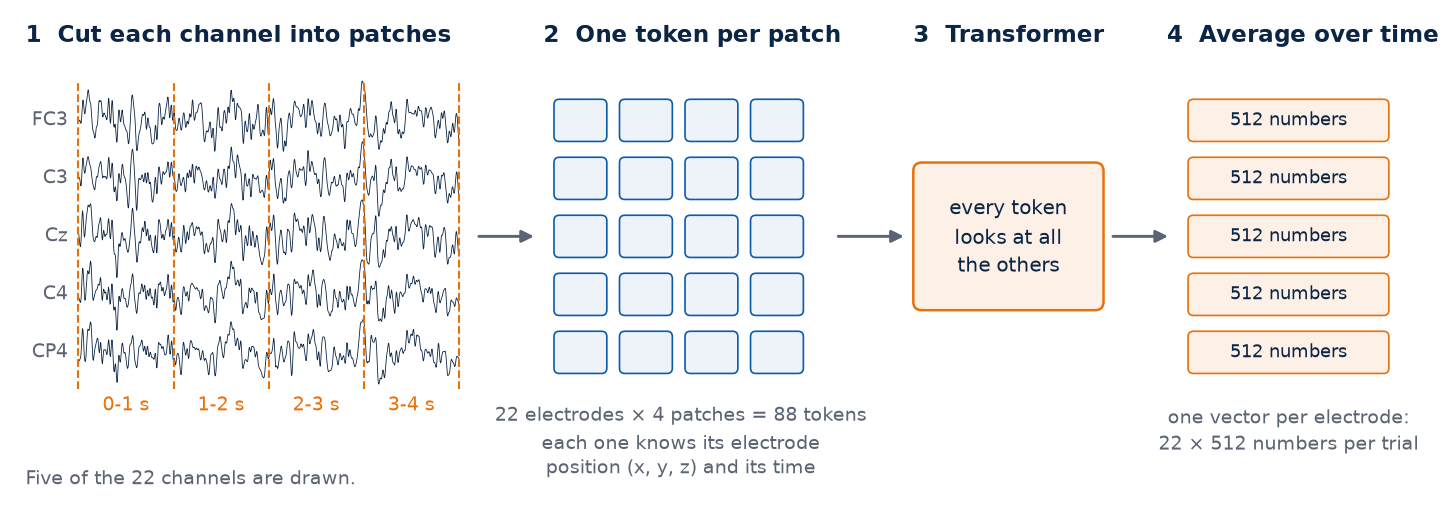

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: patches, tokens, positions</b><br>A transformer works on a sequence of pieces called <b>tokens</b>. In a language model a token is a piece of a word. REVE cuts each channel into <b>patches</b> of about one second, and each patch becomes one token: a 4 s trial with 22 channels gives 22 × 4 = 88 tokens. Each token is told <b>where and when</b> it was recorded: the position of its electrode in space (x, y, z) and its time. This is how one model can read caps with different electrodes, which is the main obstacle to pooling EEG datasets.<br>Inside the transformer, every token is updated many times using all the others (<b>attention</b>). At the output, each token is a list of 512 numbers. We average the 4 tokens of each channel, which leaves one vector of 512 numbers per electrode: <b>22 × 512 numbers per trial</b>.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What REVE expects as input

REVE was pretrained on EEG sampled at 200 Hz, where each channel of each trial was **z-scored** (mean 0, standard deviation 1). We give it the same: the 4 s after the cue, resampled from 250 to 200 Hz, filtered from 0.5 to 99.5 Hz. The decoders of notebook 2 saw 8 to 30 Hz; REVE gets almost the whole spectrum and has to find the useful part itself.

In [3]:
# ---- The trials of one participant, prepared the way REVE was pretrained
X200, y_p, meta_p = mf.load_epochs([SUBJECT], sfreq=200, fmin=0.5, fmax=99.5)
day1 = (meta_p["session"] == "0train").to_numpy()
day2 = (meta_p["session"] == "1test").to_numpy()
print("X200:", X200.shape, "(trials, channels, samples): 4 s at 200 Hz")

X200: (288, 22, 800) (trials, channels, samples): 4 s at 200 Hz


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Run REVE on a few trials

The next cell loads the pretrained model through Braindecode and passes 8 trials through it. It is here to show what goes in and what comes out. For all the trials we will read embeddings computed in advance, so this cell can be skipped (`RUN_REVE = False`).

In [4]:
# ---- Load REVE and compute the tokens of 8 trials
if RUN_REVE:
    import torch

    model = mf.load_reve(mf.CHANNELS, X200.shape[-1])                # downloads the weights the first time
    n_weights = sum(p.numel() for p in model.parameters()) / 1e6
    positions = model.get_positions(mf.CHANNELS)                     # x, y, z of each electrode
    x = torch.from_numpy(mf.reve.normalize(X200[:8]))                # z-score each channel of each trial

    start = time.time()
    with torch.no_grad():                                            # no training: we only compute the output
        tokens = model(x, pos=positions.expand(len(x), -1, -1), return_features=True)["features"]
    print(f"REVE: {n_weights:.0f} million weights, {time.time() - start:.1f} s for 8 trials on this computer")
    print("electrode positions:", tuple(positions.shape), "(electrodes, xyz)")
    print("tokens:", tuple(tokens.shape), "(trials, electrodes, patches, numbers per token)")
    fresh = tokens.mean(dim=2).numpy()                               # average the patches of each electrode
    print("embedding:", fresh.shape, "(trials, electrodes, numbers)")
else:
    print("Skipped. REVE gives 4 tokens of 512 numbers per electrode; we average them: 22 x 512 numbers per trial.")

REVE: 69 million weights, 0.2 s for 8 trials on this computer
electrode positions: (22, 3) (electrodes, xyz)
tokens: (8, 22, 4, 512) (trials, electrodes, patches, numbers per token)
embedding: (8, 22, 512) (trials, electrodes, numbers)


Each of the 22 electrodes gives 4 tokens of 512 numbers, as in the figure, and the model was told the position of each electrode. Averaging the 4 tokens gives the 22 × 512 embedding of a trial. The model has 69 million weights and none of them changes in this notebook.

## 3. The embeddings of our trials

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>An embedding cannot be read by eye. Across all trials, embeddings differ more between people than between hands.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Read the embeddings computed in advance

Running REVE on the 2,592 trials takes a few minutes on a laptop, so the result ships with the tutorial package: the **cache**. It was made with the same code as the cell above.

In [5]:
# ---- The cached embeddings of every trial
cache = mf.load_embedding_cache(SUBJECTS)
Z, y, subject, session = cache["X"], cache["y"], cache["subject"], cache["session"]
train = session == "0train"                          # day 1
test = session == "1test"                            # day 2
person = subject == SUBJECT
Z_p = Z[person]                                      # the embeddings of one participant, same trial order as X200

print("Z:", Z.shape, "(trials, electrodes, numbers)")
print("Made with:", cache["info"]["model"], "| Braindecode", cache["info"]["braindecode"])
if RUN_REVE:
    r = np.corrcoef(fresh.ravel(), Z_p[:8].ravel())[0, 1]
    print(f"Correlation between the 8 embeddings computed above and the cache: {r:.4f}")

Z: (2592, 22, 512) (trials, electrodes, numbers)
Made with: brain-bzh/reve-base | Braindecode 1.8.1
Correlation between the 8 embeddings computed above and the cache: 1.0000


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What an embedding looks like

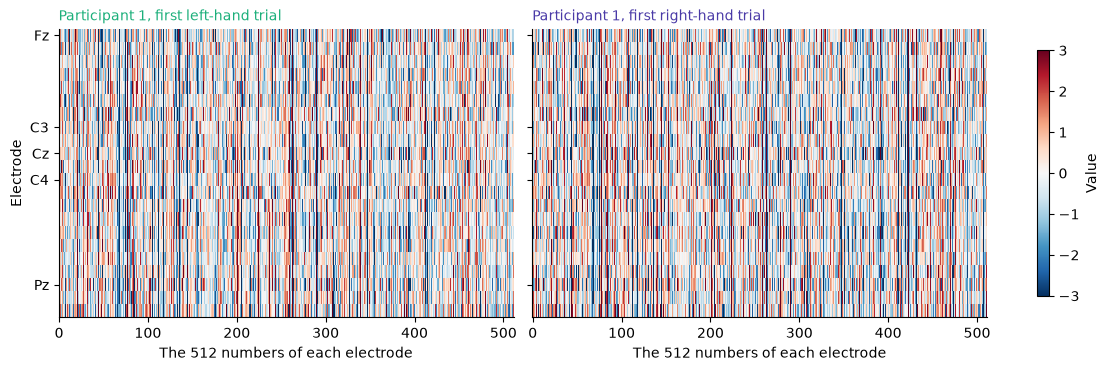

In [6]:
# ---- The embedding of one left-hand and one right-hand trial
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True, layout="constrained")
ticks = [mf.CHANNELS.index(name) for name in ["Fz", "C3", "Cz", "C4", "Pz"]]
for ax, cls in zip(axes, HANDS):
    trial = np.flatnonzero(y_p == cls)[0]
    image = ax.imshow(Z_p[trial], aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, interpolation="nearest")
    ax.set_title(f"Participant {SUBJECT}, first {cls.replace('_', '-')} trial", loc="left", fontsize=10, color=HANDS[cls])
    ax.set_xlabel("The 512 numbers of each electrode")
axes[0].set_yticks(ticks, ["Fz", "C3", "Cz", "C4", "Pz"])
axes[0].set_ylabel("Electrode")
fig.colorbar(image, ax=axes, label="Value", shrink=0.85)
plt.show()

Nothing here can be read by eye, and the two trials look alike. An embedding is not a picture of the signal: each of its numbers is a mixture computed by the network, with no unit and no name. What it contains has to be measured, which is what a probe does.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What do the embeddings organise first?

We flatten each embedding into one long vector and use **PCA** (notebook 2) to draw all the trials in the plane where they vary most, twice: coloured by participant, and coloured by imagined hand.

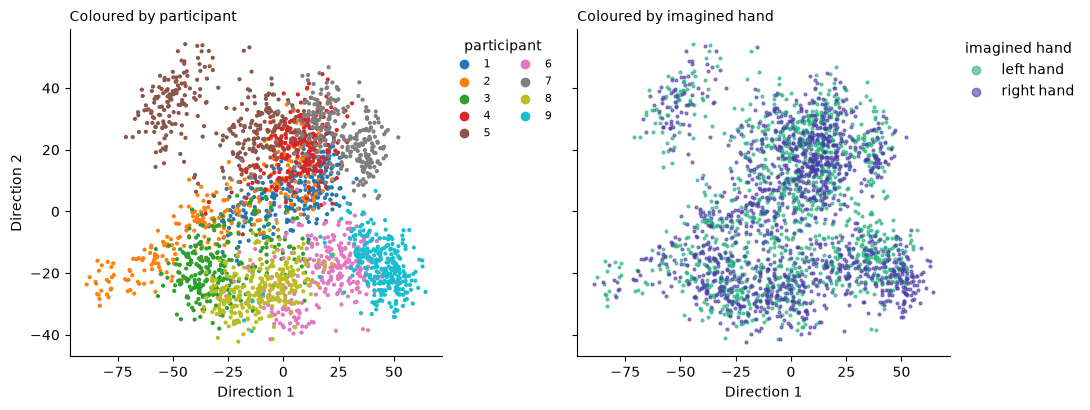

In [7]:
# ---- Every trial in the two main directions of the embeddings, coloured two ways
flat = Z.reshape(len(Z), -1)                                         # trials x (22 * 512)
plane = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(flat))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
points = axes[0].scatter(plane[:, 0], plane[:, 1], c=subject, cmap="tab10", s=4)
axes[0].legend(*points.legend_elements(), title="participant", ncols=2, fontsize=8, loc="upper left",
               bbox_to_anchor=(1.0, 1.0))
axes[0].set_title("Coloured by participant", loc="left", fontsize=10)
for cls, color in HANDS.items():
    axes[1].scatter(plane[y == cls, 0], plane[y == cls, 1], s=4, color=color, alpha=0.6, label=cls.replace("_", " "))
axes[1].legend(title="imagined hand", markerscale=3, loc="upper left", bbox_to_anchor=(1.0, 1.0))
axes[1].set_title("Coloured by imagined hand", loc="left", fontsize=10)
for ax in axes:
    ax.set_xlabel("Direction 1")
axes[0].set_ylabel("Direction 2")
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>The trials form one cloud per participant, and within each cloud the two hands are mixed. The largest differences between embeddings are differences between people. EEG differs a lot from one person to another (head shape, cap position, the rhythms themselves), and the embeddings keep that. The information about the hand may still be there, along directions with less variance. A probe looks for it with the labels.</div>

## 4. A linear probe on one participant

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A linear probe asks one question: is the information laid out simply enough in the embedding for a straight line to find it?</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> From an embedding to a vector of features

A classifier wants one row of numbers per trial. The embedding of a trial is a table, 22 electrodes × 512 numbers. Flatten it.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>array.reshape(n_rows, -1)</code> keeps the first axis and puts everything else on one row; <code>-1</code> means <i>whatever length is needed</i>. <a href='https://numpy.org/doc/stable/reference/generated/numpy.reshape.html'>numpy.reshape</a>.</div>

In [8]:
# ---- Exercise: one row of features per trial
features = ...                                       # <--- Z_p reshaped to (trials, 22 * 512)

In [9]:
#@title Solution (try first)
# ---- One row of features per trial
features = Z_p.reshape(len(Z_p), -1)
print("features:", features.shape, "(trials, features)")
print(f"{features.shape[1]} features for {day1.sum()} training trials")

features: (288, 11264) (trials, features)
11264 features for 144 training trials


<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out: more features than trials</b><br>We now have 11,264 features and 144 training trials. With far more features than trials, a classifier can always find a combination that separates the training trials perfectly, by using their noise: the <b>overfitting</b> of notebook 2, in its strongest form. Two steps keep it under control.<br><b>Standardising</b>: each feature is rescaled to mean 0 and standard deviation 1 on the training trials, so that no feature counts more because its numbers happen to be larger.<br><b>Regularisation</b>: the logistic regression pays a penalty for large weights, which pushes it towards simple rules that rely a little on many features. The parameter <code>C</code> sets the penalty: the smaller <code>C</code>, the stronger the penalty.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Build the linear probe

Two steps in a pipeline: a `StandardScaler`, then a `LogisticRegression` with the penalty `C` set in the parameters. Fit it on day 1.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))</code>. <a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html'>StandardScaler</a>, <a href='https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html'>LogisticRegression</a>. Because the scaler is inside the pipeline, it is fitted on day 1 only.</div>

In [10]:
# ---- Exercise: the linear probe, fitted on day 1
probe = ...                                          # <--- make_pipeline(StandardScaler(), LogisticRegression(...))
fitted = ...                                         # <--- probe.fit(features of day 1, labels of day 1)

In [11]:
#@title Solution (try first)
# ---- The linear probe, fitted on day 1
probe = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))
probe.fit(features[day1], y_p[day1])

on_training = balanced_accuracy_score(y_p[day1], probe.predict(features[day1]))
on_test = balanced_accuracy_score(y_p[day2], probe.predict(features[day2]))
print(f"Participant {SUBJECT}, REVE frozen + LR: {100 * on_training:.0f} % on day 1 (training), {100 * on_test:.0f} % on day 2 (test)")

Participant 1, REVE frozen + LR: 100 % on day 1 (training), 69 % on day 2 (test)


With participant 1 the probe is right for every training trial and for 69 % of the day-2 trials. A perfect training score with 11,264 features says nothing: the test score is the only one that counts. The same participant gave 83 % with CSP + LDA and 88 % with tangent space + LR in notebook 2.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> See the probe's answers

The logistic regression gives each trial one number, its **decision value**: positive means "right hand", negative "left hand", and the further from 0 the more confident.

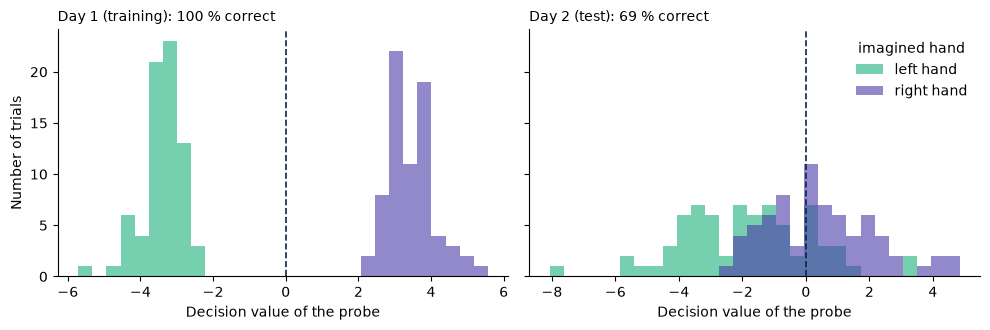

In [12]:
# ---- Decision values of the probe on each day
decision = probe.decision_function(features)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, day, name in zip(axes, [day1, day2], ["Day 1 (training)", "Day 2 (test)"]):
    bins = np.linspace(decision[day].min(), decision[day].max(), 30)
    for cls, color in HANDS.items():
        ax.hist(decision[day & (y_p == cls)], bins=bins, color=color, alpha=0.6, label=cls.replace("_", " "))
    ax.axvline(0, color="#0B2545", lw=1.2, ls="--")
    score = balanced_accuracy_score(y_p[day], probe.predict(features[day]))
    ax.set_title(f"{name}: {100 * score:.0f} % correct", loc="left", fontsize=10)
    ax.set_xlabel("Decision value of the probe")
axes[0].set_ylabel("Number of trials")
axes[1].legend(title="imagined hand")
plt.tight_layout()
plt.show()

On day 1 the two hands are far apart: the probe has learned its training trials by heart. On day 2 the two groups overlap, and both sit to the left of where they were: many right-hand trials fall on the "left" side of 0. This is the same shift between days as in the confusion matrix of notebook 2.

## 5. Where is the information?

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>REVE keeps track of where things happen: the electrodes over the motor cortex tell the hands apart best.</div>

REVE gives one vector per electrode. If it has kept track of where things happen on the head, the electrodes over the motor cortex should tell the two hands apart better than the others.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> One probe per electrode

For each participant we train 22 probes, each on the 512 numbers of a single electrode, and draw the mean score of each electrode on the head.

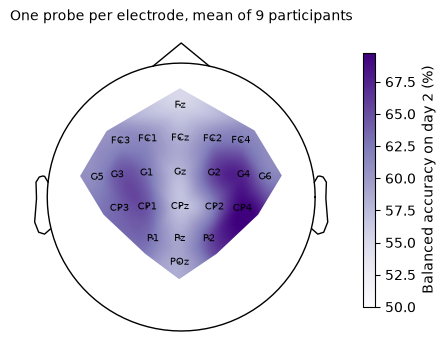

Best four electrodes: CP4 (70 %), C4 (67 %), C2 (66 %), P2 (65 %)


In [13]:
# ---- Balanced accuracy on day 2 of a probe trained on one electrode at a time, for every participant
def probe_score(features_train, y_train, features_test, y_test):
    """Fit a new probe on the training features; return its balanced accuracy on the test features."""
    model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000)).fit(features_train, y_train)
    return balanced_accuracy_score(y_test, model.predict(features_test))


per_electrode = np.mean([[probe_score(Z[(subject == s) & train][:, k], y[(subject == s) & train],
                                      Z[(subject == s) & test][:, k], y[(subject == s) & test])
                          for k in range(len(mf.CHANNELS))] for s in SUBJECTS], axis=0)      # mean over participants

info = mne.create_info(mf.CHANNELS, 250, "eeg").set_montage("standard_1020")
fig, ax = plt.subplots(figsize=(5.2, 4.4))
image, _ = mne.viz.plot_topomap(100 * per_electrode, info, axes=ax, cmap="Purples", vlim=(50, 100 * per_electrode.max()),
                                names=mf.CHANNELS, contours=0, extrapolate="local", show=False)
for text in ax.texts:
    text.set_fontsize(7)
fig.colorbar(image, ax=ax, label="Balanced accuracy on day 2 (%)", shrink=0.75)
ax.set_title(f"One probe per electrode, mean of {len(SUBJECTS)} participants", fontsize=10)
plt.show()
best = np.argsort(per_electrode)[::-1][:4]
print("Best four electrodes:", ", ".join(f"{mf.CHANNELS[k]} ({100 * per_electrode[k]:.0f} %)" for k in best))

With the 9 participants, the best probes are on the electrodes over and behind the motor cortex, on both sides (CP4 70 %, C4 67 %, C2 66 %), and the weakest are on the midline (Fz, Cz, CPz). REVE kept the information where notebook 1 found it: the vector of an electrode describes what happens near that electrode. One electrode alone reaches 70 %, and all 22 together 71 %: the probe gains little from combining them.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> One vector per trial instead of one per electrode

A common recipe averages the embedding over electrodes too, which leaves a single vector of 512 numbers per trial. Try it: average `Z_p` over its electrode axis and score a probe on the result.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>Z_p</code> has the axes (trials, electrodes, numbers): <code>Z_p.mean(axis=1)</code>. <code>probe_score(features_train, y_train, features_test, y_test)</code> is defined above.</div>

In [14]:
# ---- Exercise: a probe on the embedding averaged over electrodes
averaged = ...                                       # <--- mean of Z_p over the electrode axis: (trials, 512)
score_averaged = ...                                 # <--- probe_score on day 1 (train) and day 2 (test)

In [15]:
#@title Solution (try first)
# ---- A probe on the embedding averaged over electrodes
averaged = Z_p.mean(axis=1)
score_averaged = probe_score(averaged[day1], y_p[day1], averaged[day2], y_p[day2])
print(f"Participant {SUBJECT}: {100 * score_averaged:.0f} % with one vector per trial, {100 * on_test:.0f} % with one vector per electrode")

Participant 1: 51 % with one vector per trial, 69 % with one vector per electrode


With participant 1 the score falls to chance. Averaging over electrodes erases where things happen on the head, and for left against right hand the side of the head is the whole signal. This is why the tutorial keeps one vector per electrode. For a task where location matters less, such as sleep staging, the average may be enough.

## 6. All participants, against the classical decoders

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Make a prediction before running the next cell: will a model pretrained on 60,000 hours of EEG beat CSP, a method from the year 2000?</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The same evaluation as in notebook 2

One probe per participant, trained on day 1 and tested on day 2, with the two scores of notebook 2: balanced accuracy and ROC AUC.

In [16]:
# ---- REVE frozen + LR for every participant
def evaluate_probe(subject):
    """Fit a probe on day 1 of one participant; return its scores on day 2 and the time taken."""
    person = cache["subject"] == subject
    start = time.time()
    model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000)).fit(flat[person & train], y[person & train])
    confidence = model.predict_proba(flat[person & test])[:, list(model.classes_).index("right_hand")]
    return {"balanced_accuracy": balanced_accuracy_score(y[person & test], model.predict(flat[person & test])),
            "auc": roc_auc_score(y[person & test] == "right_hand", confidence),
            "seconds": time.time() - start}


scores = pd.DataFrame([{"method": "REVE frozen + LR", "subject": s, **evaluate_probe(s)} for s in SUBJECTS])

classical_file = RESULTS_DIR / "classical.csv"
if not classical_file.exists():
    raise FileNotFoundError("Run 02_classical.ipynb first: it saves the scores of the classical decoders.")
everything = pd.concat([pd.read_csv(classical_file), scores])
table = everything.pivot(index="method", columns="subject", values="balanced_accuracy").loc[list(COLORS), SUBJECTS]
table["mean"] = table.mean(axis=1)
(100 * table).round(0)

subject,1,2,3,4,5,6,7,8,9,mean
method,,,,,,,,,,
CSP + LDA,83.0,49.0,90.0,71.0,58.0,72.0,51.0,94.0,89.0,73.0
Tangent space + LR,88.0,59.0,96.0,75.0,59.0,73.0,56.0,97.0,85.0,76.0
REVE frozen + LR,69.0,55.0,83.0,61.0,62.0,63.0,71.0,87.0,84.0,71.0


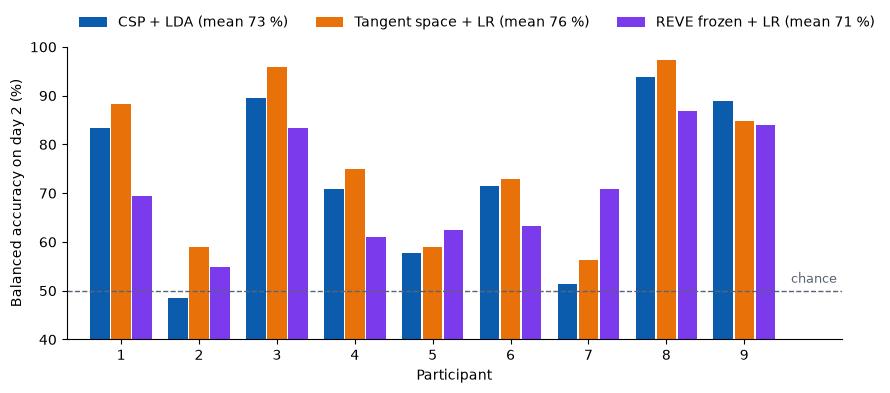

In [17]:
# ---- Balanced accuracy on day 2, per participant, for the three decoders
fig, ax = plt.subplots(figsize=(10, 3.8))
for k, (name, color) in enumerate(COLORS.items()):
    ax.bar(np.arange(len(SUBJECTS)) + 0.27 * (k - 1), 100 * table.loc[name, SUBJECTS], width=0.25, color=color,
           label=f"{name} (mean {100 * table.loc[name, 'mean']:.0f} %)")
ax.axhline(50, color="#5B6472", lw=1, ls="--")
ax.text(len(SUBJECTS) - 0.4, 51, "chance", color="#5B6472", fontsize=9, va="bottom")
ax.set_xlim(-0.7, len(SUBJECTS) + 0.25)
ax.set_xticks(range(len(SUBJECTS)), SUBJECTS)
ax.set_xlabel("Participant")
ax.set_ylabel("Balanced accuracy on day 2 (%)")
ax.set_ylim(40, 100)
ax.legend(loc="upper left", ncols=3, bbox_to_anchor=(0, 1.15))
plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, the frozen REVE with a linear probe reaches 71 % on average, below CSP + LDA (73 %) and tangent space + LR (76 %). It is lower than tangent space + LR in 7 of 9 participants. The exception is participant 7, at chance with both classical decoders and at 71 % here: the embeddings hold something about this person's imagery that power in the 8 to 30 Hz band does not. A model pretrained on 60,000 hours of EEG does not, used this way, beat methods from 2000 and 2012 on this dataset.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Save the scores

In [18]:
# ---- Save the scores for notebook 5
scores = scores.assign(training_data="own day 1", training_labels="100 %", adapted_parameters="head only", hardware="CPU")
scores.to_csv(RESULTS_DIR / "fm_frozen.csv", index=False)
print("Saved", len(scores), "rows to", RESULTS_DIR / "fm_frozen.csv")
everything.groupby("method", sort=False)[["balanced_accuracy", "auc", "seconds"]].mean().loc[list(COLORS)].round(2)

Saved 9 rows to results/fm_frozen.csv


,balanced_accuracy,auc,seconds
method,,,
CSP + LDA,0.73,0.82,0.13
Tangent space + LR,0.76,0.87,0.27
REVE frozen + LR,0.71,0.79,0.05


The time is that of the probe alone. Computing the embeddings is the expensive step, a few seconds per participant on a laptop, and it was done in advance.

## 7. With fewer labels

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Here the frozen model does not need fewer labels than the classical decoders. It needs more.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: label efficiency</b><br>Labels are the expensive part of an experiment: each labelled trial is several seconds of a person's time. The usual argument for foundation models is that they need fewer of them, because pretraining has already done most of the work. A <b>label-efficiency curve</b> tests this: train on fewer and fewer labelled trials and watch the score.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The three decoders with 10 to 144 training trials

For each size we draw the training trials at random from day 1, with as many left- as right-hand trials, five times. The test set is always the whole of day 2. The classical decoders need the trials themselves, so we load them as in notebook 2. About one minute.

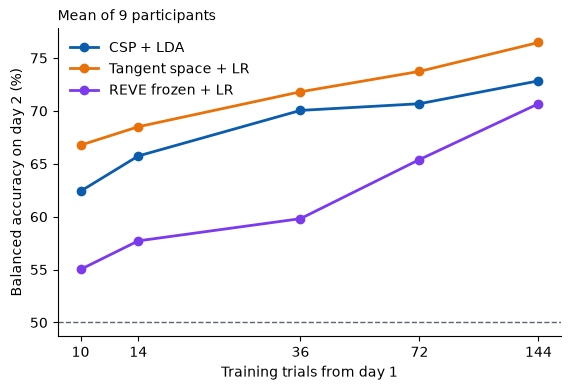

,10,14,36,72,144
CSP + LDA,62.0,66.0,70.0,71.0,73.0
Tangent space + LR,67.0,69.0,72.0,74.0,76.0
REVE frozen + LR,55.0,58.0,60.0,65.0,71.0


In [19]:
# ---- Balanced accuracy on day 2 against the number of training trials, for the three decoders
X, y_raw, _ = mf.load_epochs(SUBJECTS, fmin=8, fmax=30)                  # the input of the classical decoders
X = X.astype(np.float64)
assert (y_raw == y).all()                                                # same trials, same order as the embeddings

DECODERS = {                                                             # name -> (input, function that builds the pipeline)
    "CSP + LDA": (X, lambda: make_pipeline(CSP(n_components=4, log=True), LinearDiscriminantAnalysis())),
    "Tangent space + LR": (X, lambda: make_pipeline(Covariances(estimator="oas"), TangentSpace(),
                                                    LogisticRegression(max_iter=1000))),
    "REVE frozen + LR": (flat, lambda: make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))),
}
SIZES = [10, 14, 36, 72, 144]                                            # 5 per class, then 10, 25, 50 and 100 % of day 1


def score_with_n_trials(name, subject, n_trials, n_draws=5):
    """Mean day-2 balanced accuracy of a decoder trained on n_trials random trials of day 1."""
    inputs, make = DECODERS[name]
    person = cache["subject"] == subject
    inputs_train, y_train = inputs[person & train], y[person & train]
    if n_trials == len(y_train):
        subsets = [np.arange(len(y_train))]
    else:
        draws = StratifiedShuffleSplit(n_splits=n_draws, train_size=n_trials, random_state=0)
        subsets = [keep for keep, _ in draws.split(inputs_train, y_train)]
    return np.mean([balanced_accuracy_score(y[person & test],
                                            make().fit(inputs_train[keep], y_train[keep]).predict(inputs[person & test]))
                    for keep in subsets])


curve = pd.DataFrame({name: [np.mean([score_with_n_trials(name, s, n) for s in SUBJECTS]) for n in SIZES]
                      for name in DECODERS}, index=SIZES)

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, color in COLORS.items():
    ax.plot(curve.index, 100 * curve[name], color=color, marker="o", lw=2, label=name)
ax.axhline(50, color="#5B6472", lw=1, ls="--")
ax.set_xscale("log")
ax.set_xticks(SIZES, SIZES)
ax.minorticks_off()
ax.set_xlabel("Training trials from day 1")
ax.set_ylabel("Balanced accuracy on day 2 (%)")
ax.set_title(f"Mean of {len(SUBJECTS)} participants", loc="left", fontsize=10)
ax.legend()
plt.show()
(100 * curve).round(0).T

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, the expected advantage does not appear. The classical decoders lose 6 to 10 points between 144 and 10 training trials; the frozen REVE loses 16 and is close to chance with 10 trials (55 %). The reason is the number of features: 4 for CSP, 253 for the tangent space, 11,264 for the embedding. With 10 trials and 11,264 features a linear probe has very little to go on. Frozen embeddings help with few labels when the information sits in a few clear directions; here it does not.</div>

In [20]:
# ---- Save the curve for notebooks 4 and 5
curve.rename_axis("training_trials").to_csv(RESULTS_DIR / "label_curve.csv")
print("Saved the curve to", RESULTS_DIR / "label_curve.csv")

Saved the curve to results/label_curve.csv


## 8. Training on several participants

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>The probe on REVE gets better when it is trained on several people. The classical decoders get worse.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Why would decoders built on covariance matrices suffer when several people are pooled, while a probe on the embeddings does not?</div>

Until now every decoder was trained on one person. The embeddings of REVE are in the same space for everyone, so nothing prevents us from training **one** probe on the day 1 of all participants together. The classical pipelines can be trained that way too.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> One decoder for everyone

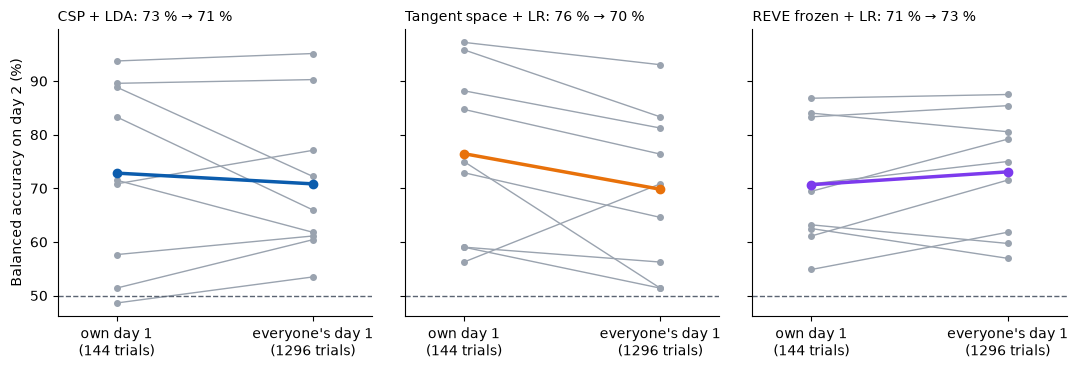

In [21]:
# ---- One decoder trained on the day 1 of all participants, tested on each participant's day 2
def pooled_scores(name):
    """Balanced accuracy on each participant's day 2 of one decoder trained on everyone's day 1."""
    inputs, make = DECODERS[name]
    model = make().fit(inputs[train], y[train])
    return [balanced_accuracy_score(y[(cache["subject"] == s) & test], model.predict(inputs[(cache["subject"] == s) & test]))
            for s in SUBJECTS]


pooled = pd.DataFrame({name: pooled_scores(name) for name in DECODERS}, index=SUBJECTS).T
pooled.T.rename_axis("subject").reset_index().melt("subject", var_name="method", value_name="balanced_accuracy").assign(
    training_data="everyone's day 1").to_csv(RESULTS_DIR / "pooled.csv", index=False)       # for notebooks 4 and 5
pooled["mean"] = pooled.mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
for ax, (name, color) in zip(axes, COLORS.items()):
    own, together = 100 * table.loc[name, SUBJECTS], 100 * pooled.loc[name, SUBJECTS]
    ax.plot([0, 1], [own, together], color="#9AA3AF", lw=1, marker="o", ms=4)
    ax.plot([0, 1], [own.mean(), together.mean()], color=color, lw=2.5, marker="o")
    ax.axhline(50, color="#5B6472", lw=1, ls="--")
    ax.set_xticks([0, 1], ["own day 1\n(144 trials)", f"everyone's day 1\n({train.sum()} trials)"])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f"{name}: {own.mean():.0f} % → {together.mean():.0f} %", loc="left", fontsize=10)
axes[0].set_ylabel("Balanced accuracy on day 2 (%)")
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, the three decoders react differently. The classical decoders get worse when the other participants are added: 73 % to 71 % for CSP + LDA, 76 % to 70 % for tangent space + LR. Spatial filters and covariance matrices are specific to a head and a cap position, so other people's trials mostly add confusion. The probe on REVE gets better, from 71 % to 73 %: its embeddings are comparable enough across people for nine times more trials to help. This is the direction in which foundation models are expected to pay off, and where the probe catches up with CSP + LDA trained per person.</div>

## 9. Go further (optional)

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> How strong should the penalty be?

We set `C = 0.01` without looking. Compute the mean day-2 score for `C` from 0.0001 to 10. How much does the choice matter? And why would it be wrong to pick the best `C` from this curve?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>Loop over <code>np.logspace(-4, 1, 6)</code> and over participants, with <code>make_pipeline(StandardScaler(), LogisticRegression(C=value, max_iter=2000))</code> on <code>flat</code>. For the second question, think of the leakage of notebook 2.</div>

In [22]:
# ---- Type 3: mean day-2 score of the probe for several values of C (optional)

In [23]:
#@title Solution (try first)
# ---- Mean day-2 score of the probe for several values of C
def probe_with_c(value, subject):
    person = cache["subject"] == subject
    model = make_pipeline(StandardScaler(), LogisticRegression(C=value, max_iter=2000)).fit(flat[person & train], y[person & train])
    return balanced_accuracy_score(y[person & test], model.predict(flat[person & test]))


by_c = pd.Series({value: np.mean([probe_with_c(value, s) for s in SUBJECTS]) for value in np.logspace(-4, 1, 6)})
(100 * by_c).round(1)
# With the 9 participants the score stays between 70 % and 71 % for C from 0.001 to 1, and drops to 68 % at both ends.
# Picking the best C from this curve would use day 2 to choose a setting: leakage. C must be chosen on day 1 only,
# for example by cross-validation inside the training trials.

0.0001     67.8
0.0010     70.0
0.0100     70.7
0.1000     70.8
1.0000     70.2
10.0000    67.7
dtype: float64

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Another classifier on the same embeddings

A logistic regression is the standard probe, not the only one. Put another linear classifier in its place and compare the mean score.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>RidgeClassifier(alpha=1000)</code> (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeClassifier.html'>documentation</a>; a larger <code>alpha</code> is a stronger penalty) or <code>LinearSVC(C=0.0001)</code> (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html'>documentation</a>). Both are imported in the cell.</div>

In [24]:
# ---- Exercise: another linear classifier on the embeddings
from sklearn.base import clone
from sklearn.linear_model import RidgeClassifier
from sklearn.svm import LinearSVC

classifier = ...                                     # <--- RidgeClassifier(alpha=1000) or LinearSVC(C=0.0001)

if classifier is not ...:                            # runs once the line above is completed
    other_scores = []
    for s in SUBJECTS:
        person = cache["subject"] == s
        model = make_pipeline(StandardScaler(), clone(classifier)).fit(flat[person & train], y[person & train])
        other_scores.append(balanced_accuracy_score(y[person & test], model.predict(flat[person & test])))
    print(f"REVE frozen + {type(classifier).__name__}: {100 * np.mean(other_scores):.0f} % | "
          f"REVE frozen + LR: {100 * table.loc['REVE frozen + LR', 'mean']:.0f} %")

In [25]:
#@title Solution (try first)
# ---- A ridge classifier on the embeddings, for every participant
from sklearn.linear_model import RidgeClassifier


def ridge_score(subject):
    person = cache["subject"] == subject
    model = make_pipeline(StandardScaler(), RidgeClassifier(alpha=1000)).fit(flat[person & train], y[person & train])
    return balanced_accuracy_score(y[person & test], model.predict(flat[person & test]))


ridge_scores = pd.Series({s: ridge_score(s) for s in SUBJECTS})
print(f"REVE frozen + ridge: {100 * ridge_scores.mean():.0f} % | REVE frozen + LR: {100 * table.loc['REVE frozen + LR', 'mean']:.0f} %")
# With the 9 participants the ridge classifier gives 70 %, the logistic regression 71 %: the classifier is not what limits the score.

REVE frozen + ridge: 70 % | REVE frozen + LR: 71 %


### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A participant the decoder has never seen

In part 8 the decoder had seen day 1 of the person it was tested on. Now leave one participant out completely: train on the other 8 (both days) and test on day 2 of the one left out. This is a decoder that needs no calibration for a new person.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>cache[&quot;subject&quot;]</code> holds the participant of each trial. <code>cache[&quot;subject&quot;] != LEFT_OUT</code> is True for the trials of everyone else.</div>

In [26]:
# ---- Exercise: train on 8 participants, test on the one left out
LEFT_OUT = 7                                         # the participant the decoders will never see
others = ...                                         # <--- True for the trials of every participant except LEFT_OUT

if others is not ...:                                # runs once the line above is completed
    held_out = (cache["subject"] == LEFT_OUT) & test
    for name in ["Tangent space + LR", "REVE frozen + LR"]:
        inputs, make = DECODERS[name]
        score = balanced_accuracy_score(y[held_out], make().fit(inputs[others], y[others]).predict(inputs[held_out]))
        print(f"{name}, never saw participant {LEFT_OUT}: {100 * score:.0f} % "
              f"(trained on their own day 1: {100 * table.loc[name, LEFT_OUT]:.0f} %)")

In [27]:
#@title Solution (try first)
# ---- Train on 8 participants, test on day 2 of the one left out
def left_out_scores(name):
    inputs, make = DECODERS[name]
    result = []
    for s in SUBJECTS:
        others, held_out = cache["subject"] != s, (cache["subject"] == s) & test
        result.append(balanced_accuracy_score(y[held_out], make().fit(inputs[others], y[others]).predict(inputs[held_out])))
    return result


left_out = pd.DataFrame({name: left_out_scores(name) for name in ["Tangent space + LR", "REVE frozen + LR"]}, index=SUBJECTS).T
left_out["mean"] = left_out.mean(axis=1)
(100 * left_out).round(0)
# With the 9 participants both reach 68 to 69 % on a person they have never seen, with no calibration trial.
# For the tangent space that is 8 points below its own-participant score (76 %); for REVE only 2 points below (71 %).

,1,2,3,4,5,6,7,8,9,mean
Tangent space + LR,87.0,48.0,92.0,55.0,52.0,66.0,67.0,82.0,64.0,68.0
REVE frozen + LR,75.0,57.0,83.0,65.0,58.0,62.0,73.0,81.0,64.0,69.0


### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> Replace REVE with another foundation model

REVE is one pretrained EEG model among several. Braindecode gives access to others with the same `from_pretrained` call: **CBraMod** (Wang et al., 2025; about 5 million weights), **LaBraM**, **EEGPT**. Compute the embeddings of our trials with one of them, train the same probe, and compare with REVE. Is the ranking of participants the same?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>braindecode.models.CBraMod.from_pretrained(&quot;braindecode/cbramod-pretrained&quot;, return_encoder_output=True, n_chans=22, n_times=800, sfreq=200, chs_info=[...])</code> (<a href='https://braindecode.org/stable/generated/braindecode.models.CBraMod.html'>documentation</a>). Called on a batch of trials at 200 Hz, it returns tokens of shape (trials, electrodes, patches, 200). Prepare the trials as for REVE (<code>mf.load_epochs(..., sfreq=200, fmin=0.5, fmax=99.5)</code>, then <code>mf.reve.normalize</code>), average the tokens over patches, flatten, and reuse the probe. The weights are a small download (about 20 MB).</div>

In [28]:
# ---- Type 3: the same probe on the embeddings of another pretrained model (optional)

In [29]:
#@title Solution (try first)
# ---- CBraMod in place of REVE: embeddings of every trial, then the same probe
import torch
from braindecode.models import CBraMod

X200_all, y200, _ = mf.load_epochs(SUBJECTS, sfreq=200, fmin=0.5, fmax=99.5)       # same input as REVE
assert (y200 == y).all()
cbramod = CBraMod.from_pretrained("braindecode/cbramod-pretrained", return_encoder_output=True, n_chans=22,
                                  n_times=X200_all.shape[-1], sfreq=200,
                                  chs_info=[{"ch_name": name} for name in mf.CHANNELS]).eval()
x = torch.from_numpy(mf.reve.normalize(X200_all))
with torch.no_grad():
    other = np.concatenate([cbramod(x[i:i + 32]).mean(dim=2).numpy() for i in range(0, len(x), 32)])
print("CBraMod embeddings:", other.shape, "(trials, electrodes, numbers)")
other = other.reshape(len(other), -1)

comparison = pd.DataFrame({
    "REVE frozen + LR": table.loc["REVE frozen + LR", SUBJECTS],
    "CBraMod frozen + LR": [probe_score(other[(subject == s) & train], y[(subject == s) & train],
                                        other[(subject == s) & test], y[(subject == s) & test]) for s in SUBJECTS]}).T
comparison["mean"] = comparison.mean(axis=1)
(100 * comparison).round(0)
# With the 9 participants CBraMod gives 59 % and REVE 71 %. CBraMod is 14 times smaller, and we fed it the input
# prepared for REVE, which is not necessarily what suits it best: a fair comparison follows each model's own recipe.
# The best participants are partly the same (3 and 8).

CBraMod embeddings: (2592, 22, 200) (trials, electrodes, numbers)


subject,1,2,3,4,5,6,7,8,9,mean
REVE frozen + LR,69.0,55.0,83.0,61.0,62.0,63.0,71.0,87.0,84.0,71.0
CBraMod frozen + LR,56.0,53.0,68.0,55.0,60.0,58.0,61.0,62.0,56.0,59.0


## 10. Summary

| Step | Function | Package |
|---|---|---|
| Trials at 200 Hz | `mf.load_epochs(sfreq=200, fmin=0.5, fmax=99.5)` | MOABB, MNE |
| Load REVE | `mf.load_reve` (`braindecode.models.REVE.from_pretrained`) | Braindecode |
| Tokens | `model(x, pos=..., return_features=True)` | Braindecode, PyTorch |
| Cached embeddings | `mf.load_embedding_cache` | tutorial package |
| Linear probe | `StandardScaler`, `LogisticRegression(C=...)` | scikit-learn |
| Head map of scores | `mne.viz.plot_topomap` | MNE |
| Fewer labels | `StratifiedShuffleSplit` | scikit-learn |
| Another pretrained model | `braindecode.models.CBraMod.from_pretrained` | Braindecode |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">Take-aways</b><br><ul style='margin:0;'><li>A foundation model is pretrained once, without labels, on a large collection of EEG. Frozen, it turns a trial into an embedding; a linear probe measures what the embedding contains.</li><li>With the 9 participants, the frozen REVE with a linear probe reaches 71 % on day 2, below CSP + LDA (73 %) and tangent space + LR (76 %).</li><li>It does not need fewer labels here: with 10 training trials it falls to 55 %, against 62 % and 67 %.</li><li>It behaves differently from the classical decoders: it decodes participant 7, and it improves when trained on several participants, where they get worse.</li><li>A frozen model with a linear probe is the simplest way to use a foundation model. Notebook 4 changes the weights.</li></ul></div>

**Next**: `04_fm_finetune.ipynb`.

<details><summary>References</summary>

- Alain, G., & Bengio, Y. (2017). Understanding intermediate layers using linear classifier probes. *International Conference on Learning Representations (workshop track)*. https://arxiv.org/abs/1610.01644
- Bommasani, R., Hudson, D. A., Adeli, E., Altman, R., Arora, S., von Arx, S., ... Liang, P. (2021). On the opportunities and risks of foundation models. *arXiv*. https://arxiv.org/abs/2108.07258
- El Ouahidi, Y., Lys, J., Thölke, P., Farrugia, N., Pasdeloup, B., Gripon, V., Jerbi, K., & Lioi, G. (2025). REVE: A foundation model for EEG, adapting to any setup with large-scale pretraining on 25,000 subjects. *Advances in Neural Information Processing Systems 38*. https://arxiv.org/abs/2510.21585
- Schirrmeister, R. T., Springenberg, J. T., Fiederer, L. D. J., Glasstetter, M., Eggensperger, K., Tangermann, M., ... Ball, T. (2017). Deep learning with convolutional neural networks for EEG decoding and visualization. *Human Brain Mapping, 38*(11), 5391-5420. https://doi.org/10.1002/hbm.23730
- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention is all you need. *Advances in Neural Information Processing Systems 30*. https://arxiv.org/abs/1706.03762
- Wang, J., Zhao, S., Luo, Z., Zhou, Y., Jiang, H., Li, S., Li, T., & Pan, G. (2025). CBraMod: A criss-cross brain foundation model for EEG decoding. *International Conference on Learning Representations*. https://arxiv.org/abs/2412.07236
</details>